# IMPORT LIBRARY
Bagian kode ini mengimpor seluruh library yang dibutuhkan untuk proses klasifikasi citra daging. Library `os` digunakan untuk manajemen file dan folder, sedangkan `cv2` (OpenCV) digunakan untuk membaca citra dari penyimpanan. `matplotlib.pyplot` dan `seaborn` digunakan untuk keperluan visualisasi, baik untuk menampilkan citra maupun grafik hasil analisis seperti heatmap korelasi. `numpy` dan `pandas` digunakan untuk manipulasi data numerik dan tabular. Untuk ekstraksi fitur tekstur, digunakan `graycomatrix` dan `graycoprops` dari `skimage.feature` serta `entropy` dari `scipy.stats`. Sementara itu, `scikit-learn` menyediakan fungsi pembagian data (`train_test_split`), tiga algoritma klasifikasi (`RandomForestClassifier`, `SVC`, `KNeighborsClassifier`), serta berbagai metrik evaluasi seperti `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`, `classification_report`, dan `ConfusionMatrixDisplay`.

In [2]:
# Import library yang kalian butuhkan
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

## Data Loading

Buat struktur folder dataset sebagai berikut:
```
.
└──dataset
    ├── label1
	├── image1.jpg
	├── image2.jpg
	└── image3.jpg
    ├── label2
    └── label3
    └── dst...
```

Kode ini digunakan untuk membaca dataset citra daging dari folder bernama `meat`, yang berisi subfolder sesuai dengan label kelas masing-masing. Untuk setiap subfolder, seluruh file gambar di dalamnya dibaca menggunakan OpenCV, kemudian dipastikan bertipe `uint8` dan dikonversi menjadi citra grayscale agar informasi warna disederhanakan menjadi satu kanal intensitas. Setiap citra yang berhasil dibaca disimpan ke dalam list `data`, nama subfolder (label kelas) disimpan ke dalam list `labels`, dan nama file gambar disimpan ke dalam list `file_name`. Setelah seluruh proses pembacaan selesai, ketiga list tersebut—`data` dan `labels`—dikonversi menjadi array numpy agar lebih mudah diproses pada tahap selanjutnya.

In [3]:
data = []
labels = []
file_name = []
for sub_folder in os.listdir("meat\\"):
    sub_folder_files = os.listdir(os.path.join("meat\\", sub_folder))
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join("meat\\", sub_folder, filename)
        img = cv.imread(img_path)
        img = img.astype(np.uint8)
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        
        data.append(img)
        labels.append(sub_folder)
        name = os.path.splitext(filename)[0]
        file_name.append(filename)
        
data = np.array(data)
labels = np.array(labels)


## Data Augmentation

### Define Augmentation Function
Bagian ini disediakan sebagai tempat untuk mendefinisikan fungsi-fungsi augmentasi citra (misalnya flip, rotasi, atau jenis augmentasi lain) yang akan digunakan untuk menambah variasi maupun jumlah data pada kelas yang datanya masih minim. Pada kode di bawah, fungsi-fungsi augmentasi belum didefinisikan dan proses augmentasi pada cell selanjutnya masih berupa kerangka (`pass`), sehingga belum ada transformasi citra yang benar-benar dilakukan pada tahap ini.

Kode ini dimaksudkan untuk melakukan augmentasi data dengan menyalin setiap citra asli beserta label dan nama filenya ke dalam list hasil augmentasi (`data_augmented`, `labels_augmented`, `file_name_augmented`, `paths_augmented`), kemudian menambahkan versi-versi augmentasi (misalnya hasil flip atau rotasi) dari citra tersebut sesuai kebutuhan. Namun, pada kondisi kode saat ini, badan perulangan masih berisi `pass`, sehingga proses augmentasi belum diimplementasikan dan keempat list hasil augmentasi tersebut masih kosong setelah cell ini dijalankan.

In [4]:
# melakukan augmentasi data
data_augmented = []
labels_augmented = []
paths_augmented = []
file_name_augmented = []
for i in range(len(data)):
	pass

Kode ini digunakan untuk membandingkan jumlah data sebelum dan sesudah proses augmentasi, dengan mencetak panjang list `data` (jumlah citra asli) dan panjang list `data_augmented` (jumlah citra setelah augmentasi). Karena pada cell sebelumnya proses augmentasi belum diimplementasikan, maka jumlah data setelah augmentasi akan bernilai 0, yang menunjukkan bahwa fungsi augmentasi masih perlu dilengkapi terlebih dahulu agar data benar-benar bertambah.

In [5]:
print("Data sebelum augmentasi: ", len(data))
print("Data setelah augmentasi: ", len(data_augmented))

Data sebelum augmentasi:  2000
Data setelah augmentasi:  0


## Data Preparation

### Define Preprocessing Function
Bagian ini berisi definisi fungsi-fungsi preprocessing yang akan digunakan untuk mengolah citra sebelum masuk ke tahap ekstraksi fitur. Pada percobaan ini, preprocessing diimplementasikan secara manual (tanpa memanggil fungsi siap pakai dari OpenCV) menggunakan kombinasi histogram equalization dan gaussian blur.

Kode ini mendefinisikan tiga fungsi preprocessing yang diimplementasikan secara manual menggunakan perulangan dan operasi numpy. Fungsi `histogram_equalization` menghitung histogram intensitas piksel dari citra grayscale, mengubahnya menjadi PDF (probability density function) dan CDF (cumulative distribution function), lalu menggunakan CDF tersebut sebagai fungsi transformasi untuk meratakan distribusi intensitas piksel sehingga kontras citra menjadi lebih jelas. Fungsi `gaussian_kernel` membangun kernel Gaussian berdasarkan ukuran (`size`) dan nilai sebaran (`sigma`) yang ditentukan, dengan setiap elemen kernel dihitung menggunakan rumus distribusi Gaussian dua dimensi dan kemudian dinormalisasi agar jumlah seluruh elemennya sama dengan satu. Fungsi `convolution` melakukan operasi konvolusi antara citra dan kernel dengan menambahkan padding di sekeliling citra, menggeser kernel ke setiap posisi piksel, mengalikan dan menjumlahkan nilai pada area tersebut, lalu membatasi (clip) hasilnya ke rentang nilai piksel yang valid (0-255). Terakhir, fungsi `gaussian_blur` menggabungkan `gaussian_kernel` dan `convolution` untuk menghasilkan citra yang telah dihaluskan (blur) menggunakan kernel Gaussian, yang berguna untuk mengurangi noise pada citra sebelum tahap ekstraksi fitur tekstur.

**Alasan pemilihan metode:** Citra daging pada umumnya memiliki variasi pencahayaan dan kontras yang cukup besar antar foto, tergantung kondisi pengambilan gambar (sumber cahaya, jarak kamera, jenis kamera, dsb). Histogram equalization dipilih karena mampu meratakan distribusi intensitas piksel sehingga detail tekstur permukaan daging—yang menjadi informasi utama untuk membedakan kelas—menjadi lebih terlihat jelas, tidak terlalu gelap atau terlalu terang. Sementara itu, gaussian blur dipilih sebagai tahap pelengkap untuk meredam noise berfrekuensi tinggi (bintik-bintik kecil akibat sensor kamera atau kompresi gambar) yang dapat mengganggu perhitungan fitur tekstur GLCM pada tahap berikutnya. Kombinasi kedua metode ini bertujuan agar citra yang masuk ke tahap ekstraksi fitur memiliki kontras yang konsisten namun tetap halus, sehingga fitur tekstur yang diekstrak lebih representatif dan tidak didominasi oleh noise.

In [6]:
def histogram_equalization(gray):

    h, w = gray.shape
    total_pixels = h * w

    histogram = np.zeros(256)

    for i in range(h):
        for j in range(w):
            histogram[gray[i, j]] += 1

    pdf = histogram / total_pixels

    cdf = np.zeros(256)
    cdf[0] = pdf[0]

    for i in range(1, 256):
        cdf[i] = cdf[i-1] + pdf[i]

    transform = np.round(cdf * 255).astype(np.uint8)

    equalized = np.zeros_like(gray)

    for i in range(h):
        for j in range(w):
            equalized[i, j] = transform[gray[i, j]]

    return equalized

def gaussian_kernel(size=5, sigma=1.0):

    kernel = np.zeros((size, size))

    center = size // 2

    for x in range(size):
        for y in range(size):

            dx = x - center
            dy = y - center

            kernel[x, y] = (
                np.exp(-(dx**2 + dy**2)/(2*sigma**2))
                /(2*np.pi*sigma**2)
            )

    kernel = kernel / np.sum(kernel)

    return kernel

def convolution(image, kernel):

    h, w = image.shape

    k = kernel.shape[0]
    pad = k // 2

    padded = np.pad(
        image,
        ((pad, pad), (pad, pad)),
        mode='constant'
    )

    output = np.zeros((h, w))

    for i in range(h):
        for j in range(w):

            region = padded[i:i+k, j:j+k]

            output[i, j] = np.sum(region * kernel)

    output = np.clip(output, 0, 255)

    return output.astype(np.uint8)

def gaussian_blur(image,
                            kernel_size=5,
                            sigma=1.0):

    kernel = gaussian_kernel(
        size=kernel_size,
        sigma=sigma
    )

    blurred = convolution(
        image,
        kernel
    )

    return blurred

Kode ini digunakan untuk menguji coba fungsi preprocessing yang telah didefinisikan sebelumnya pada satu sampel citra, yaitu `data[0]`. Citra tersebut pertama-tama diproses dengan `histogram_equalization` untuk meratakan distribusi intensitasnya, kemudian hasilnya diproses lebih lanjut dengan `gaussian_blur` untuk menghaluskan citra. Hasil akhir citra yang telah melalui kedua tahap tersebut kemudian ditampilkan menggunakan `plt.imshow` dengan colormap grayscale, sebagai bentuk pengecekan visual sebelum fungsi-fungsi ini diterapkan pada seluruh dataset.

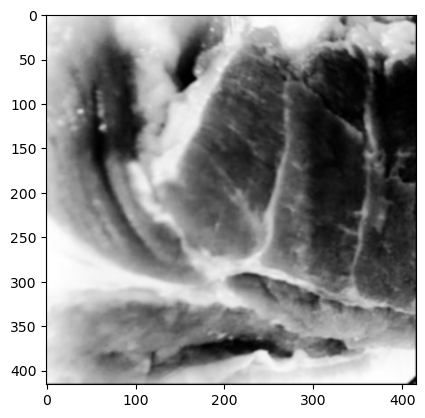

In [7]:
img_tes_base = histogram_equalization(data[0])
imggaus = gaussian_blur(img_tes_base)



plt.imshow(imggaus, cmap='gray')
plt.show()

Kode ini mendefinisikan fungsi `percobaan1` sebagai pembungkus (wrapper) yang menggabungkan tahapan histogram equalization dan gaussian blur menjadi satu fungsi preprocessing yang akan dipanggil untuk setiap citra dalam dataset. Di dalam fungsi ini, citra input diproses menggunakan `histogram_equalization_manual` lalu hasilnya diteruskan ke `gaussian_blur_manual`. Perlu dicatat bahwa nama kedua fungsi yang dipanggil di sini (`histogram_equalization_manual` dan `gaussian_blur_manual`) berbeda dengan nama fungsi yang telah didefinisikan pada cell sebelumnya (`histogram_equalization` dan `gaussian_blur`), sehingga fungsi `percobaan1` ini akan menghasilkan error apabila dijalankan kecuali kedua fungsi dengan suffix `_manual` tersebut didefinisikan terlebih dahulu di tempat lain.

In [8]:
#
def percobaan1(img):
    img_tes_base = histogram_equalization(img)
    imggaus = gaussian_blur(img_tes_base)
    
    return imggaus

### Preprocessing

Kode ini menerapkan fungsi preprocessing `percobaan1` ke seluruh citra dalam `data` secara berurutan menggunakan perulangan, dan menyimpan hasilnya ke dalam list `dataPreprocessed`. Setelah seluruh citra diproses, list tersebut dikonversi menjadi array numpy dan ukurannya (`shape`) ditampilkan sebagai informasi bahwa proses preprocessing telah selesai. Sebagai pengecekan visual, satu sampel hasil preprocessing (`dataPreprocessed[0]`) ditampilkan beserta label kelasnya untuk memastikan citra hasil olahan tampak sesuai harapan.

Memulai proses preprocessing...
Preprocessing Selesai! Ukuran data: (2000, 416, 416)


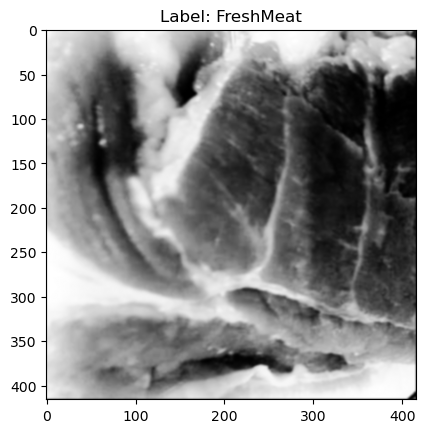

In [9]:
dataPreprocessed = []
print("Memulai proses preprocessing...")

for i in range(len(data)): 
    # Data[i] mentah masuk ke percobaan3, 
    # lalu otomatis di-grayscale & resize dulu, baru di-morfologi
    img_hasil = percobaan1(data[i]) 
    
    dataPreprocessed.append(img_hasil)

dataPreprocessed = np.array(dataPreprocessed)
print("Preprocessing Selesai! Ukuran data:", dataPreprocessed.shape)

# Tampilkan sampel
plt.imshow(dataPreprocessed[0], cmap='gray')
plt.title(f"Label: {labels[0]}")
plt.show()

### Feature Extraction

Kode ini mendefinisikan fungsi `glcm` untuk menghitung *Gray-Level Co-occurrence Matrix* (GLCM) dari citra grayscale berdasarkan sudut tertentu (0, 45, 90, atau 135 derajat). Fungsi menerima input citra dan derajat sudut, kemudian mengonversi sudut tersebut ke radian yang diperlukan oleh fungsi `graycomatrix` dari library `skimage.feature`. GLCM dihitung dengan jarak piksel 1, diatur agar simetris dan ternormalisasi. Matriks GLCM ini sangat berguna untuk ekstraksi fitur tekstur pada tahap selanjutnya.

**Alasan pemilihan metode:** GLCM dipilih sebagai metode ekstraksi fitur karena klasifikasi citra daging segar dan busuk pada dasarnya lebih ditentukan oleh karakteristik tekstur permukaan (kasar, halus, berserat, berlendir, dsb) dibandingkan oleh bentuk objek atau warna semata. GLCM menangkap hubungan statistik antara pasangan piksel yang bertetangga pada jarak dan arah tertentu, sehingga mampu merepresentasikan pola tekstur tersebut secara kuantitatif. Penggunaan empat arah sudut (0°, 45°, 90°, 135°) bertujuan agar tekstur yang mungkin tidak seragam ke segala arah (anisotropik) tetap dapat tertangkap secara lebih lengkap, dibandingkan hanya menggunakan satu arah saja.

In [10]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")
    
    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

Kode ini mendefinisikan fungsi `correlation` yang digunakan untuk mengekstrak fitur korelasi dari matriks GLCM (Gray-Level Co-occurrence Matrix). Fungsi memanfaatkan `graycoprops` dari library `skimage.feature` dengan parameter `'correlation'` untuk menghitung tingkat korelasi antar piksel dalam citra berdasarkan GLCM yang diberikan. Nilai korelasi ini menggambarkan hubungan linier antara intensitas piksel yang berdekatan dan dapat menjadi fitur penting dalam membedakan tekstur antar kelas citra daging.

In [11]:
def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

Kode ini mendefinisikan fungsi `dissimilarity` untuk mengambil fitur dissimilarity dari matriks GLCM (Gray-Level Co-occurrence Matrix). Fungsi menggunakan `graycoprops` dari `skimage.feature` dengan parameter `'dissimilarity'` untuk mengukur seberapa berbeda intensitas piksel yang berdekatan dalam citra. Nilai dissimilarity ini membantu dalam menangkap variasi tekstur dan perbedaan lokal pada citra, yang berguna untuk proses klasifikasi citra.

In [12]:
def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

Kode ini mendefinisikan fungsi `homogenity` yang digunakan untuk mengekstrak fitur homogeneity dari matriks GLCM (Gray-Level Co-occurrence Matrix). Fungsi memanfaatkan `graycoprops` dari library `skimage.feature` dengan parameter `'homogeneity'` untuk mengukur seberapa seragam tekstur dalam citra, yaitu seberapa dekat distribusi elemen dalam GLCM ke diagonal utamanya. Nilai homogeneity yang tinggi menunjukkan tekstur yang lebih seragam, yang dapat membantu membedakan karakteristik tekstur antar kelas citra daging.

In [13]:
def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

Kode ini mendefinisikan fungsi `contrast` untuk mengekstrak fitur contrast dari matriks GLCM (Gray-Level Co-occurrence Matrix). Fungsi menggunakan `graycoprops` dari `skimage.feature` dengan parameter `'contrast'` untuk mengukur perbedaan intensitas lokal dalam citra. Nilai contrast yang tinggi menunjukkan adanya variasi tekstur yang kuat, sehingga fitur ini berguna untuk membedakan pola dan tekstur pada citra dalam proses klasifikasi.

In [14]:
def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

Kode ini mendefinisikan fungsi `ASM` untuk mengekstrak fitur Angular Second Moment (ASM) dari matriks GLCM (Gray-Level Co-occurrence Matrix). Fungsi menggunakan `graycoprops` dari `skimage.feature` dengan parameter `'ASM'`, yang mengukur tingkat keseragaman atau energi tekstur dalam citra. Nilai ASM yang tinggi menunjukkan tekstur yang lebih homogen dan teratur, sehingga fitur ini membantu dalam analisis dan klasifikasi pola tekstur citra daging.

In [15]:
def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

Kode ini mendefinisikan fungsi `energy` yang digunakan untuk mengekstrak fitur energy dari matriks GLCM (Gray-Level Co-occurrence Matrix). Fungsi memanfaatkan `graycoprops` dari library `skimage.feature` dengan parameter `'energy'`, yang merupakan akar kuadrat dari Angular Second Moment (ASM) dan mencerminkan keseragaman tekstur dalam citra. Nilai energy yang tinggi menunjukkan tekstur yang lebih konsisten dan beraturan, sehingga fitur ini penting untuk proses klasifikasi.

In [16]:
def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

Kode ini mendefinisikan fungsi `entropyGlcm` untuk menghitung fitur entropy dari matriks GLCM (Gray-Level Co-occurrence Matrix). Fungsi menggunakan `entropy` dari modul `scipy.stats` pada matriks GLCM yang telah diratakan (dirubah menjadi vektor satu dimensi) untuk mengukur tingkat ketidakteraturan atau kompleksitas tekstur citra. Nilai entropy yang tinggi menunjukkan tekstur yang lebih acak dan tidak teratur, sehingga fitur ini membantu dalam membedakan karakteristik tekstur antar kelas citra.

In [17]:
def entropyGlcm(matriks):
    return entropy(matriks.ravel())

## Ekstraksi GLCM pada Berbagai Derajat
Kode ini melakukan ekstraksi Gray-Level Co-occurrence Matrix (GLCM) dari setiap citra dalam `dataPreprocessed` pada empat arah sudut yang berbeda: 0°, 45°, 90°, dan 135°. Dengan menggunakan fungsi `glcm`, setiap citra diproses untuk menghasilkan matriks GLCM pada masing-masing derajat tersebut, yang kemudian disimpan dalam list terpisah (`Derajat0`, `Derajat45`, `Derajat90`, `Derajat135`). Ekstraksi pada berbagai arah ini berguna untuk menangkap tekstur citra secara lebih menyeluruh, karena pola tekstur dapat bervariasi tergantung arah pengamatannya.

In [18]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

## Inisialisasi Variabel untuk Fitur GLCM
Kode ini membuat beberapa list kosong untuk menyimpan nilai fitur tekstur yang diekstrak dari matriks GLCM pada masing-masing sudut 0°, 45°, 90°, dan 135°. Fitur-fitur tersebut meliputi kontras (contrast), dissimilarity, homogenitas (homogeneity), entropi (entropy), angular second moment (ASM), energi (energy), dan korelasi (correlation). Setiap fitur memiliki empat list terpisah sesuai dengan arah ekstraksi GLCM, yang nantinya akan diisi dengan nilai-nilai hasil ekstraksi pada cell-cell berikutnya.

In [19]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []


## Ekstraksi Fitur Korelasi dari GLCM pada Berbagai Derajat
Kode ini menghitung nilai fitur korelasi (correlation) dari matriks GLCM yang sudah diekstraksi pada empat sudut berbeda (0°, 45°, 90°, dan 135°) untuk setiap citra dalam `dataPreprocessed`. Fungsi `correlation()` digunakan untuk mengambil nilai korelasi dari masing-masing matriks GLCM, kemudian hasilnya disimpan ke dalam list yang sesuai (`correlation0`, `correlation45`, `correlation90`, `correlation135`).

In [20]:
for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

## Ekstraksi Fitur Kontras dari GLCM pada Berbagai Derajat
Kode ini melakukan perhitungan nilai fitur kontras (contrast) dari matriks GLCM yang telah diekstraksi pada sudut 0°, 45°, 90°, dan 135° untuk setiap citra. Fungsi `contrast()` digunakan untuk memperoleh nilai kontras dari masing-masing matriks GLCM, kemudian nilai-nilai tersebut disimpan dalam list terpisah (`Kontras0`, `Kontras45`, `Kontras90`, dan `Kontras135`). Perlu diperhatikan bahwa perulangan pada cell ini menggunakan `len(data)` sebagai acuan jumlah iterasi, bukan `len(dataPreprocessed)` seperti pada cell ekstraksi GLCM sebelumnya, sehingga jumlah iterasi akan tetap konsisten selama panjang `data` dan `dataPreprocessed` sama.

In [21]:
for i in range(len(data)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

## Ekstraksi Fitur Dissimilarity dari GLCM pada Berbagai Derajat
Kode ini mengekstrak nilai fitur dissimilarity dari matriks GLCM yang dihasilkan pada sudut 0°, 45°, 90°, dan 135° untuk setiap citra. Fungsi `dissimilarity()` digunakan untuk menghitung tingkat perbedaan intensitas antar piksel pada citra, kemudian hasilnya disimpan dalam list terpisah (`dissimilarity0`, `dissimilarity45`, `dissimilarity90`, dan `dissimilarity135`).

In [22]:
for i in range(len(data)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

## Ekstraksi Fitur Homogeneity dari GLCM pada Berbagai Derajat
Kode ini melakukan ekstraksi fitur homogeneity dari matriks GLCM untuk sudut 0°, 45°, 90°, dan 135° pada setiap citra. Fungsi `homogenity()` digunakan untuk mengukur keseragaman atau tingkat kemiripan intensitas piksel yang berdekatan, dan hasilnya disimpan dalam list `homogenity0`, `homogenity45`, `homogenity90`, dan `homogenity135`.

In [23]:
for i in range(len(data)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

## Ekstraksi Fitur Entropy dari GLCM pada Berbagai Derajat
Kode ini mengekstrak fitur entropy dari matriks GLCM untuk sudut 0°, 45°, 90°, dan 135° pada setiap citra. Fungsi `entropyGlcm()` menghitung entropi, yaitu ukuran ketidakteraturan atau kompleksitas tekstur citra, dari nilai-nilai matriks GLCM yang diratakan. Nilai entropy ini kemudian disimpan dalam list `entropy0`, `entropy45`, `entropy90`, dan `entropy135`.

In [24]:
for i in range(len(data)):  
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

## Ekstraksi Fitur ASM (Angular Second Moment) dari GLCM pada Berbagai Derajat
Kode ini menghitung fitur Angular Second Moment (ASM) dari matriks GLCM untuk sudut 0°, 45°, 90°, dan 135° pada setiap citra. ASM adalah ukuran homogenitas tekstur yang tinggi, menunjukkan seberapa seragam pola tekstur pada citra. Nilai ASM dari setiap derajat disimpan ke dalam list `ASM0`, `ASM45`, `ASM90`, dan `ASM135`.

In [25]:
for i in range(len(data)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

## Ekstraksi Fitur Energy dari GLCM pada Berbagai Derajat
Kode ini menghitung fitur Energy dari matriks GLCM untuk sudut 0°, 45°, 90°, dan 135° pada setiap citra. Energy merupakan akar kuadrat dari ASM dan mengukur kekompakan atau keteraturan tekstur dalam citra. Nilai energy untuk tiap derajat disimpan dalam list `energy0`, `energy45`, `energy90`, dan `energy135`.

In [26]:
for i in range(len(data)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

### Write the extraction's results to CSV
Kode ini menggabungkan seluruh fitur tekstur hasil ekstraksi GLCM dari berbagai derajat (0°, 45°, 90°, 135°) beserta label dan nama file gambar ke dalam sebuah dictionary bernama `dataTable`. Dictionary ini kemudian diubah menjadi DataFrame menggunakan pandas dan disimpan ke file CSV bernama `'hasil_ekstraksi_1.csv'` tanpa menyertakan indeks. Selanjutnya, file CSV tersebut dibaca kembali ke dalam variabel `hasilEkstrak` untuk memastikan data tersimpan dengan benar dan siap digunakan pada tahap seleksi fitur.

In [27]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_1.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_1.csv')
hasilEkstrak


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,0001.jpg,FreshMeat,36.713305,79.473474,45.497515,82.625420,0.335123,0.263980,0.334517,0.249415,...,0.000385,0.000271,0.019959,0.016923,0.019621,0.016448,0.996488,0.992412,0.995655,0.992111
1,0002.jpg,FreshMeat,85.623888,138.602659,71.186562,160.669340,0.272561,0.230913,0.270588,0.209057,...,0.000327,0.000238,0.018677,0.016530,0.018074,0.015418,0.991489,0.986220,0.992915,0.984026
2,0003.jpg,FreshMeat,66.540385,129.466105,63.156968,118.687078,0.290084,0.222585,0.268210,0.216387,...,0.000295,0.000232,0.018657,0.015251,0.017184,0.015223,0.993497,0.987338,0.993817,0.988392
3,0004.jpg,FreshMeat,17.655763,47.283013,26.955248,39.340758,0.490267,0.372033,0.441099,0.384268,...,0.000559,0.000444,0.025880,0.020915,0.023646,0.021077,0.998353,0.995587,0.997481,0.996328
4,0005.jpg,FreshMeat,80.859291,128.773035,72.397776,166.134011,0.250847,0.215096,0.272492,0.193256,...,0.000313,0.000199,0.016642,0.015324,0.017691,0.014099,0.991976,0.987231,0.992811,0.983526
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0996.jpg,RottenMeat,109.787205,173.758217,63.334106,164.959756,0.252858,0.199708,0.303777,0.199283,...,0.000365,0.000214,0.017053,0.014664,0.019110,0.014641,0.989337,0.983108,0.993850,0.983963
1996,0997.jpg,RottenMeat,85.121750,216.623278,142.281204,227.921649,0.250658,0.158440,0.201787,0.154615,...,0.000186,0.000136,0.015529,0.011696,0.013638,0.011644,0.991522,0.978379,0.985820,0.977251
1997,0998.jpg,RottenMeat,142.388896,217.231976,74.299259,205.744921,0.204091,0.156995,0.253444,0.160797,...,0.000248,0.000142,0.013840,0.011852,0.015743,0.011901,0.985858,0.978411,0.992631,0.979553
1998,0999.jpg,RottenMeat,99.337025,162.225664,76.729026,179.735631,0.252095,0.189818,0.245998,0.186324,...,0.000246,0.000176,0.016300,0.013434,0.015685,0.013263,0.990374,0.984274,0.992565,0.982576


### Features Selection

pada bagian seleksi fitur ini bisa menggunakan metode seperti
- PCA
- LDA
- t-SNE
- Chi-square
- ANOVA
- Autoencoder
- correlation
- dll

berikut contoh menggunakan correlation:

Kode ini melakukan seleksi fitur menggunakan pendekatan korelasi antar fitur. Pertama, dihitung matriks korelasi antar seluruh kolom fitur pada `hasilEkstrak` (setelah kolom `Label` dan `Filename` dihapus). Selanjutnya, ditentukan sebuah `threshold` (di sini diatur sebesar 0.95) sebagai batas korelasi absolut antar dua fitur; apabila korelasi antara dua fitur melebihi batas tersebut, salah satu dari kedua fitur tersebut akan ditandai untuk dihapus (`columns[j] = False`) karena dianggap membawa informasi yang redundan. Fitur-fitur yang tersisa setelah penyaringan ini disimpan dalam `select`, dan digunakan untuk membentuk dataset fitur baru `x_new`, sementara label kelas disimpan dalam `y`. Sebagai langkah verifikasi, hasil korelasi antar fitur yang tersisa divisualisasikan menggunakan heatmap dari `seaborn` agar lebih mudah diamati apakah masih terdapat fitur dengan korelasi tinggi setelah proses penyaringan.

**Alasan pemilihan metode:** Karena fitur GLCM diekstraksi pada empat arah sudut (0°, 45°, 90°, 135°) untuk tujuh jenis fitur tekstur, total terdapat 28 kolom fitur yang berpotensi banyak mengandung redundansi—misalnya nilai contrast pada sudut 0° dan 45° kemungkinan besar berkorelasi tinggi karena berasal dari citra yang sama. Pendekatan korelasi dipilih karena sederhana, cepat dihitung, dan langsung dapat mengidentifikasi pasangan fitur yang hampir membawa informasi yang sama (redundan) tanpa perlu melibatkan label kelas. Dengan menghapus salah satu fitur dari setiap pasangan yang berkorelasi tinggi, dimensi data dapat dikurangi sehingga model klasifikasi menjadi lebih ringan dan berpotensi mengurangi risiko overfitting akibat fitur yang terlalu banyak dan saling tumpang tindih.

<Axes: >

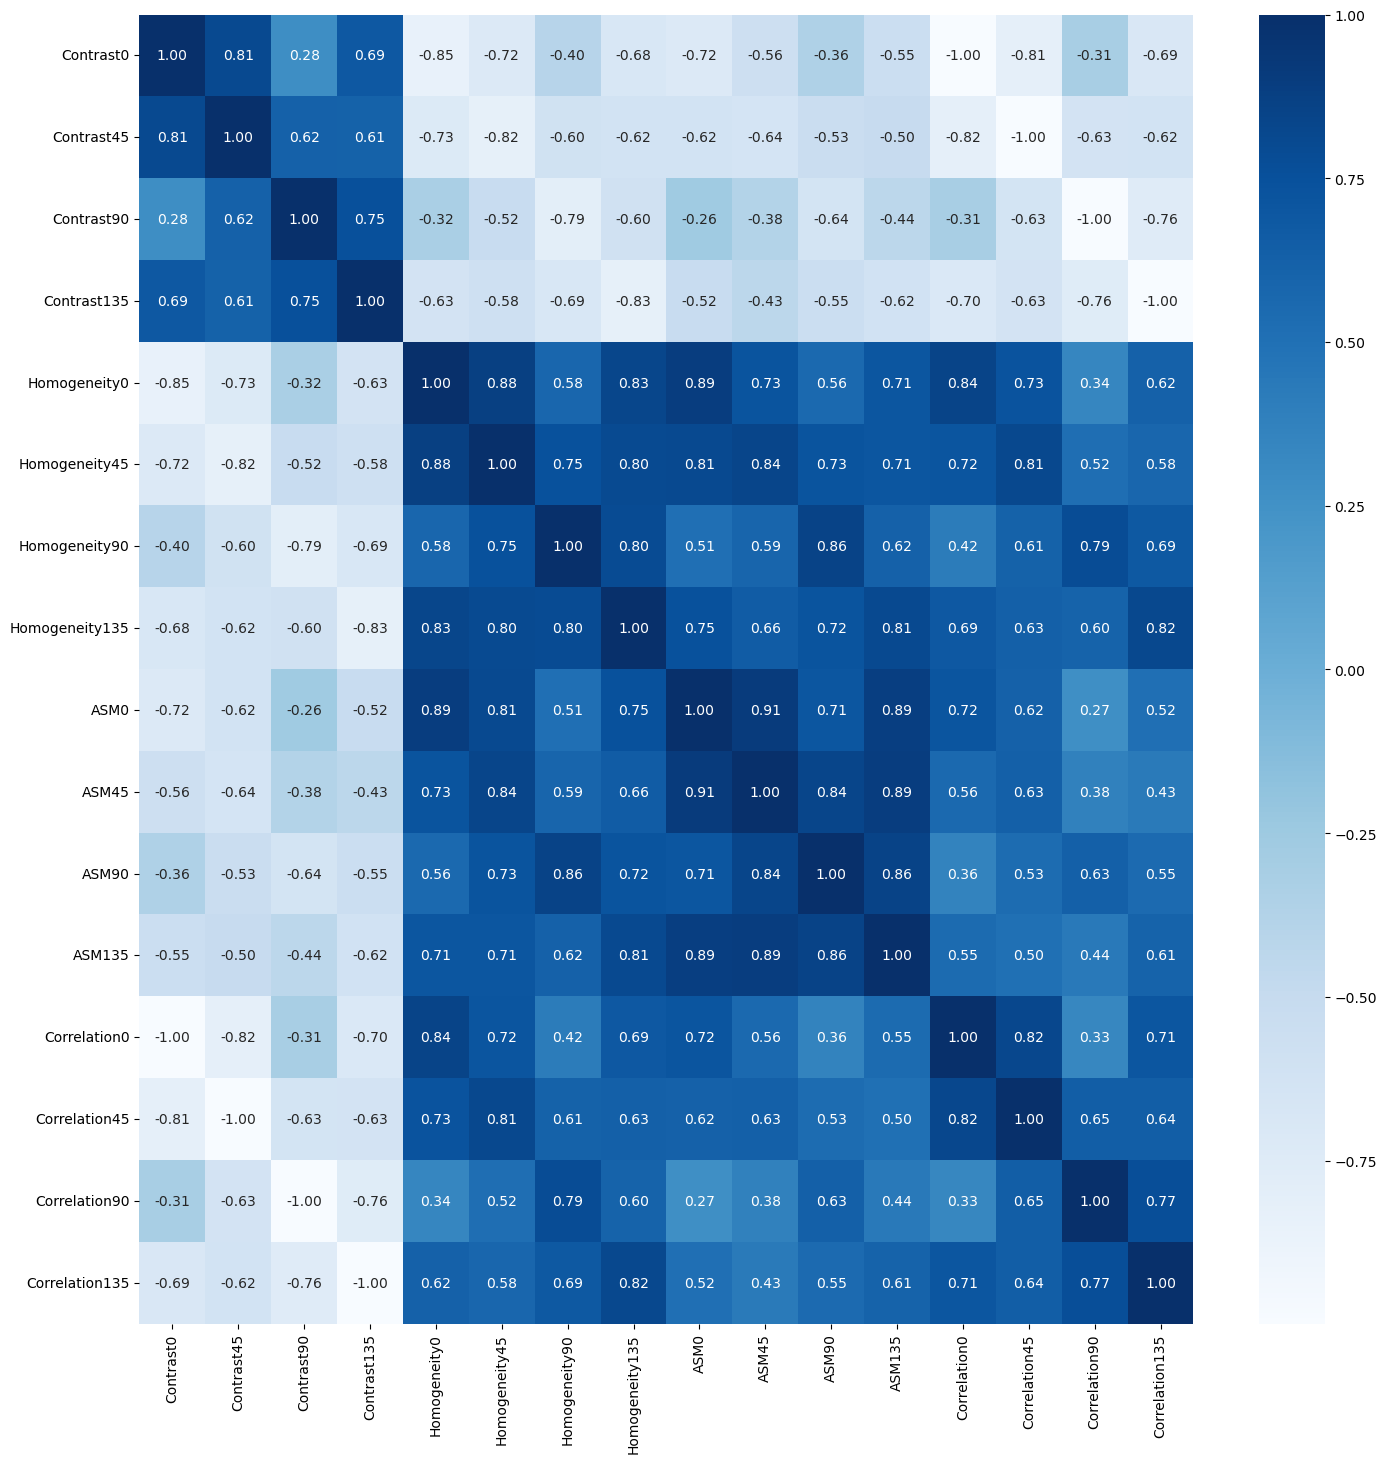

In [28]:
# Menghitung korelasi
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")

## Splitting Data

Kode ini melakukan pembagian dataset fitur (`x_new`) dan label (`y`) menjadi data pelatihan (train) dan pengujian (test) menggunakan fungsi `train_test_split` dari scikit-learn. Parameter `test_size=0.2` menunjukkan bahwa 20% data dialokasikan untuk testing, sedangkan 80% sisanya untuk training. Pengaturan `random_state=42` digunakan agar pembagian data ini konsisten dan dapat direproduksi. Setelah pembagian, kode mencetak bentuk (shape) dari dataset train dan test untuk memastikan proporsi pembagian data sudah sesuai yang diharapkan.

In [29]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(1600, 16)
(400, 16)


## Feature Normalization

berikut metode normalisasi yang bisa digunakan:
- Min-Max Scaling
- Standardization (Z-score)
- Robust Scaling
- MaxAbsScaler
- dll

berikut contoh menggunakan Standardization (Z-score):

Kode ini melakukan normalisasi fitur pada data train dan test menggunakan metode standardisasi (z-score normalization). Data train dinormalisasi dengan mengurangi nilai rata-rata (`mean`) dan membagi dengan standar deviasi (`std`) dari data train itu sendiri, agar fitur memiliki distribusi dengan rata-rata 0 dan standar deviasi 1. Data test juga dinormalisasi menggunakan mean dan std yang sama dari data train (bukan dari data test) agar skala kedua dataset konsisten dan tidak terjadi kebocoran informasi (data leakage) dari data test ke proses normalisasi.

**Alasan pemilihan metode:** Fitur-fitur tekstur GLCM (contrast, homogeneity, energy, entropy, dsb) memiliki rentang nilai yang sangat berbeda satu sama lain—misalnya entropy dapat bernilai jauh lebih besar dibandingkan correlation yang berada pada rentang -1 hingga 1. Standardisasi (z-score) dipilih karena menyetarakan skala seluruh fitur ke distribusi dengan rata-rata 0 dan standar deviasi 1, sehingga tidak ada satu fitur pun yang mendominasi proses pembelajaran model hanya karena rentang nilainya lebih besar. Hal ini penting terutama untuk algoritma seperti SVM dan KNN yang sangat sensitif terhadap skala fitur, karena kedua algoritma tersebut mengandalkan perhitungan jarak atau margin antar titik data.

In [30]:
# normalisasi mean std
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

## Modeling

### Define Model

Kode ini mendefinisikan fungsi `generateClassificationReport` untuk mencetak laporan evaluasi model klasifikasi yang mencakup classification report (precision, recall, f1-score), confusion matrix, dan akurasi. Selain itu, tiga algoritma klasifikasi didefinisikan: Random Forest dengan 5 pohon keputusan (`n_estimators=5`), Support Vector Machine (SVM) dengan kernel RBF, dan K-Nearest Neighbors (KNN) dengan 5 tetangga (`n_neighbors=5`). Ketiga model ini akan digunakan dan dibandingkan performanya pada tahap pelatihan dan evaluasi selanjutnya.

**Alasan pemilihan ketiga algoritma:** Random Forest, SVM, dan KNN dipilih karena ketiganya merepresentasikan tiga pendekatan klasifikasi yang berbeda secara fundamental, sehingga perbandingan di antara ketiganya dapat memberikan gambaran metode mana yang paling cocok untuk karakteristik fitur tekstur GLCM pada dataset citra daging ini. Random Forest mewakili pendekatan berbasis ensemble pohon keputusan yang membagi ruang fitur berdasarkan aturan threshold pada tiap fitur secara bertahap, SVM mewakili pendekatan berbasis margin yang mencari batas pemisah optimal antar kelas, dan KNN mewakili pendekatan berbasis kemiripan (instance-based) yang mengklasifikasikan data baru berdasarkan kedekatannya dengan data latih. Ketiga algoritma ini juga relatif ringan secara komputasi dan cocok digunakan pada dataset berukuran kecil hingga menengah seperti pada eksperimen ini, di mana jumlah fitur sudah direduksi melalui tahap feature selection sebelumnya.

In [31]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

### Train Random Forest Classifier

Kode ini melatih model Random Forest menggunakan data latih (`X_train`, `y_train`). Setelah pelatihan selesai, model digunakan untuk melakukan prediksi pada data latih dan data uji (`X_test`). Hasil prediksi tersebut kemudian dievaluasi dengan fungsi `generateClassificationReport` yang menampilkan classification report, confusion matrix, dan akurasi untuk kedua set data. Tujuan dari langkah ini adalah untuk mengetahui seberapa baik model dapat mengklasifikasikan data latih maupun data yang belum pernah dilihat sebelumnya, serta untuk mendeteksi indikasi overfitting apabila akurasi pada data latih jauh lebih tinggi dibandingkan data uji.

**Analisis algoritma Random Forest:** Random Forest bekerja dengan membangun banyak pohon keputusan (decision tree) secara independen, di mana setiap pohon dilatih menggunakan sub-sampel data dan sub-set fitur yang dipilih secara acak (bagging), kemudian hasil prediksi akhirnya diambil melalui voting mayoritas dari seluruh pohon. Pada eksperimen ini, jumlah pohon yang digunakan relatif sedikit (`n_estimators=5`), sehingga keragaman antar pohon menjadi terbatas dan performa model sangat bergantung pada kualitas masing-masing pohon individu; jumlah pohon yang lebih besar umumnya dapat meningkatkan stabilitas dan akurasi prediksi karena variansi model semakin berkurang. Kelebihan Random Forest adalah kemampuannya menangani fitur yang tidak perlu dinormalisasi secara ketat dan relatif tahan terhadap overfitting dibandingkan satu pohon keputusan tunggal, namun karena jumlah pohon yang sedikit pada kode ini, model masih berpotensi kurang stabil terutama jika data latih berjumlah kecil seperti pada kasus klasifikasi citra daging ini.

In [32]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

   FreshMeat       0.99      0.99      0.99       801
  RottenMeat       0.99      0.99      0.99       799

    accuracy                           0.99      1600
   macro avg       0.99      0.99      0.99      1600
weighted avg       0.99      0.99      0.99      1600

[[790  11]
 [  8 791]]
Accuracy: 0.988125

------Testing Set------
              precision    recall  f1-score   support

   FreshMeat       0.86      0.86      0.86       199
  RottenMeat       0.87      0.87      0.87       201

    accuracy                           0.86       400
   macro avg       0.86      0.86      0.86       400
weighted avg       0.86      0.86      0.86       400

[[172  27]
 [ 27 174]]
Accuracy: 0.865


### Train SVM Classifier

Kode ini melatih model Support Vector Machine (SVM) dengan kernel RBF menggunakan data latih (`X_train`, `y_train`). Setelah model dilatih, prediksi dilakukan pada data latih dan data uji (`X_test`). Fungsi `generateClassificationReport` digunakan untuk menampilkan metrik evaluasi seperti classification report, confusion matrix, dan akurasi pada kedua set data. Langkah ini bertujuan mengukur performa model SVM dalam mengklasifikasikan citra daging berdasarkan fitur tekstur GLCM yang telah diekstraksi dan diseleksi sebelumnya.

**Analisis algoritma SVM:** SVM bekerja dengan mencari hyperplane (bidang pemisah) yang memaksimalkan margin antara dua kelas pada ruang fitur, dan dengan menggunakan kernel RBF (Radial Basis Function), SVM mampu memetakan data ke ruang dimensi yang lebih tinggi sehingga dapat memisahkan kelas yang tidak dapat dipisahkan secara linear pada ruang fitur aslinya. Pendekatan ini cocok diterapkan pada fitur GLCM yang telah dinormalisasi menggunakan z-score, karena SVM dengan kernel RBF sangat sensitif terhadap skala fitur—fitur yang tidak ternormalisasi dapat menyebabkan margin yang terbentuk menjadi bias terhadap fitur dengan rentang nilai yang lebih besar. SVM umumnya bekerja baik pada dataset dengan jumlah fitur yang relatif sedikit namun informatif (seperti hasil seleksi fitur korelasi pada eksperimen ini), serta cenderung lebih tahan terhadap overfitting dibandingkan model yang lebih kompleks apabila jumlah data latih terbatas.

In [33]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

   FreshMeat       0.88      0.90      0.89       801
  RottenMeat       0.90      0.88      0.89       799

    accuracy                           0.89      1600
   macro avg       0.89      0.89      0.89      1600
weighted avg       0.89      0.89      0.89      1600

[[719  82]
 [ 94 705]]
Accuracy: 0.89

------Testing Set------
              precision    recall  f1-score   support

   FreshMeat       0.86      0.83      0.84       199
  RottenMeat       0.84      0.86      0.85       201

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.85      0.85      0.85       400

[[166  33]
 [ 28 173]]
Accuracy: 0.8475


### Train KNN Classifier

Kode ini melatih model K-Nearest Neighbors (KNN) dengan `k=5` menggunakan data latih (`X_train`, `y_train`). Setelah pelatihan selesai, model melakukan prediksi pada data latih dan data uji (`X_test`). Fungsi `generateClassificationReport` kemudian digunakan untuk menampilkan hasil evaluasi berupa classification report, confusion matrix, dan akurasi untuk kedua set data tersebut. Proses ini bertujuan untuk menilai kemampuan model KNN dalam mengklasifikasikan fitur tekstur citra daging berdasarkan jarak terhadap tetangga terdekatnya.

**Analisis algoritma KNN:** KNN merupakan algoritma berbasis instance (instance-based learning) yang tidak membangun model eksplisit pada saat pelatihan, melainkan menyimpan seluruh data latih dan melakukan klasifikasi pada saat prediksi dengan menghitung jarak (umumnya jarak Euclidean) antara data baru dan seluruh data latih, kemudian menentukan kelas berdasarkan mayoritas label dari `k=5` tetangga terdekat. Karena KNN sangat bergantung pada perhitungan jarak antar titik data, normalisasi z-score yang dilakukan sebelumnya menjadi krusial agar setiap fitur GLCM memberikan kontribusi yang seimbang terhadap perhitungan jarak, tanpa normalisasi tersebut fitur dengan rentang nilai besar akan mendominasi hasil perhitungan jarak. Kelemahan utama KNN adalah biaya komputasi pada saat prediksi yang meningkat seiring jumlah data latih, serta sensitivitasnya terhadap pemilihan nilai `k`—nilai `k` yang terlalu kecil dapat membuat model rentan terhadap noise, sedangkan nilai `k` yang terlalu besar dapat membuat batas antar kelas menjadi terlalu halus dan mengabaikan pola lokal pada data.

In [34]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)



------Training Set------


              precision    recall  f1-score   support

   FreshMeat       0.92      0.93      0.93       801
  RottenMeat       0.93      0.92      0.93       799

    accuracy                           0.93      1600
   macro avg       0.93      0.93      0.93      1600
weighted avg       0.93      0.93      0.93      1600

[[746  55]
 [ 62 737]]
Accuracy: 0.926875

------Testing Set------
              precision    recall  f1-score   support

   FreshMeat       0.86      0.85      0.86       199
  RottenMeat       0.86      0.86      0.86       201

    accuracy                           0.86       400
   macro avg       0.86      0.86      0.86       400
weighted avg       0.86      0.86      0.86       400

[[170  29]
 [ 28 173]]
Accuracy: 0.8575


## Evaluation With Confusion Matrix

Kode ini mendefinisikan fungsi `plot_confusion_matrix` untuk memvisualisasikan matriks kebingungan (confusion matrix) dari hasil prediksi model klasifikasi. Fungsi menerima label asli (`y_true`), prediksi model (`y_pred`), dan judul grafik sebagai input, kemudian menampilkan heatmap confusion matrix dengan palet warna biru. Fungsi ini kemudian dipanggil untuk ketiga model yang telah dilatih: Random Forest, SVM, dan KNN, guna menampilkan perbandingan visual performa masing-masing model dalam mengklasifikasikan citra daging pada data uji.

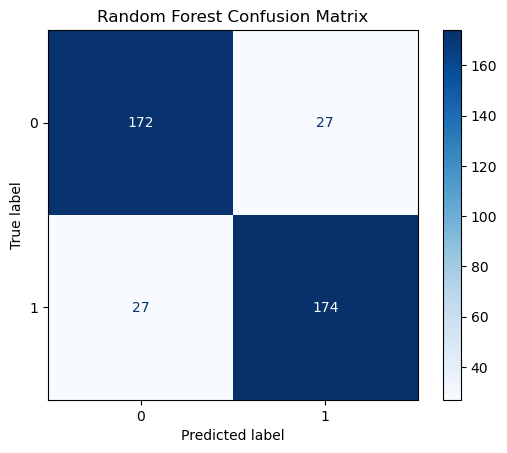

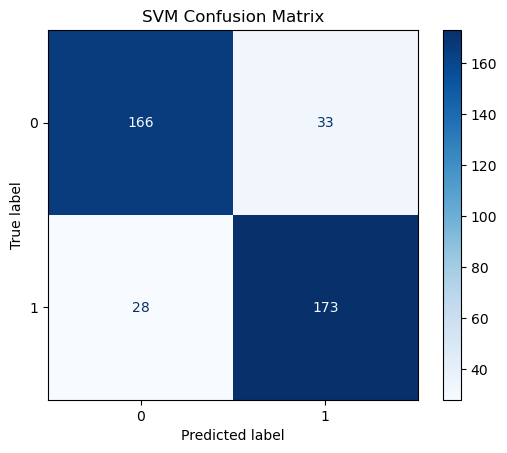

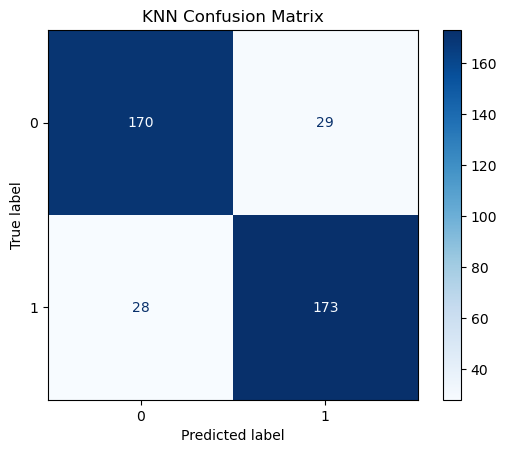

In [35]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")